## CONTEO DE ZIP POR MES

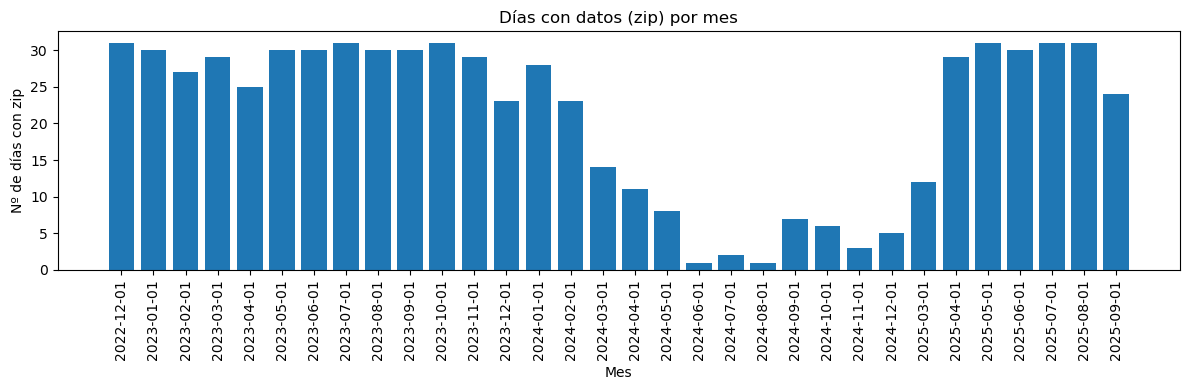

,dias_con_zip
2022-12,31
2023-01,30
2023-02,27
2023-03,29
2023-04,25
2023-05,30
2023-06,30
2023-07,31
2023-08,30
2023-09,30


In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

carpeta = Path(r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\estat_trafic_VLC-main")

# dd-mm-yyyy.zip
pat = re.compile(r"^(\d{2}-\d{2}-\d{4})\.zip$", re.IGNORECASE)

# Extraer fechas de los nombres de los zip
fechas = []
for p in carpeta.glob("*.zip"):
    m = pat.match(p.name)
    if m:
        fechas.append(m.group(1))

dias = pd.to_datetime(pd.Series(fechas), format="%d-%m-%Y", errors="coerce").dropna()
dias = pd.Series(dias.dt.normalize().unique()).sort_values()

# Conteo de días con zip por mes
conteo_mes = dias.dt.to_period("M").value_counts().sort_index()

# Pasar índice a timestamp para graficar más cómodo
x = conteo_mes.index.to_timestamp()

plt.figure(figsize=(12, 4))
plt.bar(x.astype(str), conteo_mes.values)
plt.title("Días con datos (zip) por mes")
plt.xlabel("Mes")
plt.ylabel("Nº de días con zip")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# (Opcional) ver la tabla debajo
display(conteo_mes.rename("dias_con_zip").to_frame())

## MARZO - CONTEO ZIP, Y DIAS EXACTOS

In [2]:
from pathlib import Path
import re
import pandas as pd

carpeta = Path(r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\estat_trafic_VLC-main")
pat = re.compile(r"^(\d{2}-\d{2}-\d{4})\.zip$", re.IGNORECASE)

# Fechas (dd-mm-yyyy) sacadas del nombre de cada zip
fechas = []
for p in carpeta.glob("*.zip"):
    m = pat.match(p.name)
    if m:
        fechas.append(m.group(1))

dias = pd.to_datetime(pd.Series(fechas), format="%d-%m-%Y", errors="coerce").dropna()
dias = pd.Series(dias.dt.normalize().unique()).sort_values()

# Filtrar SOLO marzo (de cualquier año)
marzo = dias[dias.dt.month == 3].sort_values()

# Mostrar exactamente qué días hay, con año incluido
# (formato YYYY-MM-DD)
print(f"Días disponibles en marzo (todos los años): {len(marzo)}")
display(marzo.dt.strftime("%Y-%m-%d").reset_index(drop=True).to_frame("fecha"))

# (Opcional) resumen por año: cuántos días de marzo hay en cada año
resumen_anio = marzo.dt.year.value_counts().sort_index()
display(resumen_anio.rename("dias_de_marzo_con_zip").to_frame())

Días disponibles en marzo (todos los años): 55


,fecha
0,2023-03-01
1,2023-03-02
2,2023-03-03
3,2023-03-04
4,2023-03-05
5,2023-03-06
6,2023-03-07
7,2023-03-08
8,2023-03-09
9,2023-03-10


,dias_de_marzo_con_zip
2023,29
2024,14
2025,12


## CONTEO DIAS, DE NOMBRE ARCHIVOS 

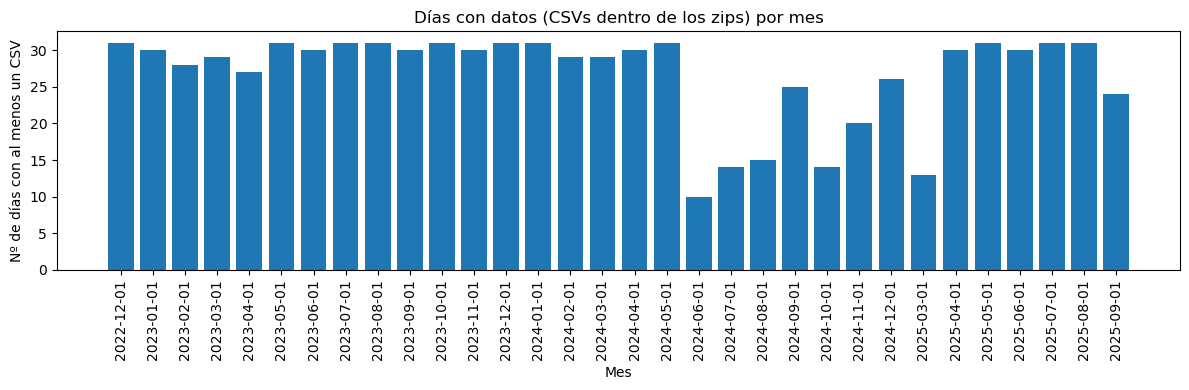

,dias_con_csv
2022-12,31
2023-01,30
2023-02,28
2023-03,29
2023-04,27
2023-05,31
2023-06,30
2023-07,31
2023-08,31
2023-09,30


In [3]:
from pathlib import Path
import re
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

carpeta = Path(r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\estat_trafic_VLC-main")

# Fecha desde CSV dentro del zip: estat_traf01-01-2023_00-00-02.csv
pat_csv = re.compile(r"estat_traf(\d{2}-\d{2}-\d{4})_", re.IGNORECASE)

dias = []
for zpath in sorted(carpeta.glob("*.zip")):
    try:
        with zipfile.ZipFile(zpath, "r") as z:
            for name in z.namelist():
                base = Path(name).name
                m = pat_csv.search(base)
                if m:
                    dias.append(m.group(1))
    except zipfile.BadZipFile:
        print("Zip corrupto o inválido:", zpath.name)

dias = pd.to_datetime(pd.Series(dias), format="%d-%m-%Y", errors="coerce").dropna()
dias = pd.Series(dias.dt.normalize().unique()).sort_values()

# Conteo de días con CSV por mes
conteo_mes = dias.dt.to_period("M").value_counts().sort_index()
x = conteo_mes.index.to_timestamp()

plt.figure(figsize=(12, 4))
plt.bar(x.astype(str), conteo_mes.values)
plt.title("Días con datos (CSVs dentro de los zips) por mes")
plt.xlabel("Mes")
plt.ylabel("Nº de días con al menos un CSV")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(conteo_mes.rename("dias_con_csv").to_frame())

## DATOS DESCOMPRIMIDOS

CSVs detectados con fecha: 80740
Días únicos detectados: 854
Rango: 2022-12-01 -> 2025-09-24


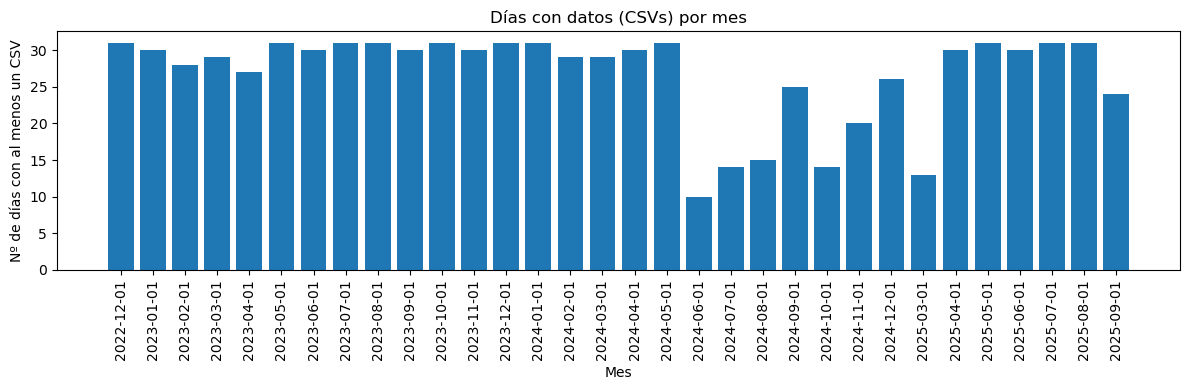

,dias_con_csv
2022-12,31
2023-01,30
2023-02,28
2023-03,29
2023-04,27
2023-05,31
2023-06,30
2023-07,31
2023-08,31
2023-09,30



Días faltantes en el rango observado: 175


,primeros_faltantes
0,2023-01-31
1,2023-03-16
2,2023-03-22
3,2023-04-01
4,2023-04-07
5,2023-04-11
6,2024-03-18
7,2024-03-19
8,2024-06-06
9,2024-06-07


In [4]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# 1) Carpeta donde están los CSV sueltos
carpeta = Path(r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\data")  # <-- ajusta si hace falta

# 2) Fecha desde el nombre: estat_traf01-01-2023_00-00-02.csv  -> 01-01-2023
pat = re.compile(r"^estat_traf(\d{2}-\d{2}-\d{4})_", re.IGNORECASE)

# 3) Recoger fechas desde nombres de CSV
fechas = []
for p in carpeta.glob("*.csv"):
    m = pat.match(p.name)
    if m:
        fechas.append(m.group(1))

dias = pd.to_datetime(pd.Series(fechas), format="%d-%m-%Y", errors="coerce").dropna()
dias = pd.Series(dias.dt.normalize().unique()).sort_values()

print("CSVs detectados con fecha:", len(fechas))
print("Días únicos detectados:", len(dias))
print("Rango:", dias.min().date(), "->", dias.max().date())

# 4) Conteo de días con CSV por mes
conteo_mes = dias.dt.to_period("M").value_counts().sort_index()
x = conteo_mes.index.to_timestamp()

plt.figure(figsize=(12, 4))
plt.bar(x.astype(str), conteo_mes.values)
plt.title("Días con datos (CSVs) por mes")
plt.xlabel("Mes")
plt.ylabel("Nº de días con al menos un CSV")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(conteo_mes.rename("dias_con_csv").to_frame())

# 5) (Opcional) días faltantes en el rango observado
rango = pd.date_range(dias.min(), dias.max(), freq="D")
faltantes = rango.difference(dias)
print("\nDías faltantes en el rango observado:", len(faltantes))
display(pd.Series(faltantes).dt.strftime("%Y-%m-%d").head(30).to_frame("primeros_faltantes"))

## DISTRIBUCION DE LOS ZIPS, DIA REAL, ZIP EN EL QUE ESTA

In [5]:
from pathlib import Path
import re
import zipfile
import pandas as pd

# Carpeta con los .zip
carpeta = Path(r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\estat_trafic_VLC-main")

pat_csv = re.compile(r"estat_traf(\d{2}-\d{2}-\d{4})_", re.IGNORECASE)

rows = []

for zpath in sorted(carpeta.glob("*.zip")):
    try:
        with zipfile.ZipFile(zpath, "r") as z:
            conteo_por_dia = {}
            for name in z.namelist():
                base = Path(name).name
                m = pat_csv.search(base)
                if m:
                    d = pd.to_datetime(m.group(1), format="%d-%m-%Y", errors="coerce")
                    if pd.notna(d):
                        d = d.normalize()
                        conteo_por_dia[d] = conteo_por_dia.get(d, 0) + 1

            for d, n in conteo_por_dia.items():
                # 🔹 Ya NO filtramos por mes
                rows.append({"fecha": d, "zip": zpath.name, "n_csv": n})

    except zipfile.BadZipFile:
        print("Zip corrupto o inválido:", zpath.name)

tabla = pd.DataFrame(rows)

if tabla.empty:
    print("No se encontraron días en los CSVs de los zips.")
else:
    # ordenar
    tabla = tabla.sort_values(["fecha", "zip"]).reset_index(drop=True)

    
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 0)

    tabla["fecha"] = tabla["fecha"].dt.strftime("%Y-%m-%d")
    tabla.head(30)

## MERGE

In [ ]:
import pandas as pd
import re
from pathlib import Path

# ── CONFIGURACIÓN ──────────────────────────────────────────────────────────────
CARPETA_DATOS  = r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\data"
ARCHIVO_FILTRO = r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\Zonas_conservar_organizadas.xlsx"
ARCHIVO_SALIDA = r"C:\Users\vicen\OneDrive\Escritorio\3_Curso\PROYECTOIII\resultado_filtrado.csv"

COL_ID = "gid"

PATRON_FECHA = re.compile(
    r"estat_traf(\d{2}-\d{2}-\d{4})_(\d{2}-\d{2}-\d{2})\.csv",
    re.IGNORECASE
)
# ───────────────────────────────────────────────────────────────────────────────


def extraer_datetime(nombre_archivo: str):
    m = PATRON_FECHA.match(nombre_archivo)
    if not m:
        return None
    fecha_str, hora_str = m.group(1), m.group(2)
    return pd.to_datetime(
        f"{fecha_str} {hora_str.replace('-', ':')}",
        format="%d-%m-%Y %H:%M:%S"
    )


def main():
    # 1) Leer Excel con los gid a conservar
    df_filtro = pd.read_excel(ARCHIVO_FILTRO)

    if COL_ID not in df_filtro.columns:
        raise ValueError(f"No existe la columna '{COL_ID}' en el Excel de filtro")

    gids_validos = set(
        pd.to_numeric(df_filtro[COL_ID], errors="coerce")
        .dropna()
        .astype(int)
    )

    print(f"GIDs a conservar: {len(gids_validos)}")

    # 2) Buscar CSVs
    archivos_csv = sorted(Path(CARPETA_DATOS).glob("estat_traf*.csv"))
    print(f"Archivos CSV encontrados: {len(archivos_csv)}")

    trozos = []
    sin_coincidencia = []

    for ruta in archivos_csv:
        nombre = ruta.name
        dt = extraer_datetime(nombre)

        if dt is None:
            print(f"⚠ No se pudo extraer fecha/hora de: {nombre}")
            continue

        try:
            df = pd.read_csv(ruta, sep=None, engine="python", encoding="utf-8")
        except UnicodeDecodeError:
            df = pd.read_csv(ruta, sep=None, engine="python", encoding="latin1")

        if COL_ID not in df.columns:
            print(f"⚠ El archivo {nombre} no tiene la columna '{COL_ID}'")
            continue

        # Convertir gid a numérico de forma segura
        df[COL_ID] = pd.to_numeric(df[COL_ID], errors="coerce")

        # Filtrar solo los gid del Excel
        df = df[df[COL_ID].isin(gids_validos)].copy()

        # Quitar NaN y dejar gid como entero si quieres
        df = df.dropna(subset=[COL_ID])
        df[COL_ID] = df[COL_ID].astype(int)

        if df.empty:
            sin_coincidencia.append(nombre)
            continue

        # Añadir fecha y hora extraída del nombre del archivo
        df.insert(0, "fecha_hora", dt)

        trozos.append(df)
        print(f"✓ {nombre} → {len(df)} filas")

    if not trozos:
        print("No se encontraron filas que coincidan con los GIDs del Excel.")
        return

    # 3) Unir todo y guardar
    resultado = pd.concat(trozos, ignore_index=True)
    resultado.to_csv(ARCHIVO_SALIDA, index=False, encoding="utf-8-sig")

    print(f"\n✅ Resultado guardado en: {ARCHIVO_SALIDA}")
    print(f"Filas totales: {len(resultado)}")
    print(f"Archivos sin coincidencias: {len(sin_coincidencia)}")


if __name__ == "__main__":
    main()

In [6]:
import pandas as pd

df2 = pd.read_csv("resultado_filtrado.csv")

C:\Users\vicen\AppData\Local\Temp\ipykernel_26720\1598683589.py:3: DtypeWarning: Columns (7,8,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("resultado_filtrado.csv")


In [7]:
df2.isna().sum()

fecha_hora                             0
gid                                    0
Denominació / Denominación             0
Estat / Estado                         0
Id. Tram / Id. Tramo                   0
created_user                    11593151
created_date                    11593151
last_edited_user                11587841
last_edited_date                11587841
geo_shape                              0
geo_point_2d                           0
fiwareid                         8476352
Distritos (pertenece)                  0
Distritos (se dirige)            5916500
Anillos                           799524
Salidas/Entrada                  6795989
Direccion (Solo intraanillo)     4237496
dtype: int64

In [8]:
print(df2['gid'].nunique())

145


In [9]:
df2.head()

,fecha_hora,gid,Denominació / Denominación,Estat / Estado,Id. Tram / Id. Tramo,created_user,created_date,last_edited_user,last_edited_date,geo_shape,geo_point_2d,fiwareid,Distritos (pertenece),Distritos (se dirige),Anillos,Salidas/Entrada,Direccion (Solo intraanillo)
0,2023-01-01 00:00:02,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,5,393.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.40307502980039567, 39.469...","39.46968578972779,-0.4059148701576997",NaN,7,3,De 4 a 3,3 (Entrada),NaN
1,2023-01-01 00:00:02,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),0,51.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.37693460997582384, 39.472...","39.47049109929769,-0.37811268049966074",NaN,FUERA,FUERA,FUERA,FUERA,FUERA
2,2023-01-01 00:00:02,1954,MENORCA HACIA AV. DEL PUERTO,0,198.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.34661534511317676, 39.456...","39.458985865466786,-0.34290002968190025",NaN,12,13,4,NaN,Antihorario
3,2023-01-01 00:00:02,1955,SERRERIA HACIA BLASCO IBAÑEZ,0,199.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.3345894648899924, 39.4696...","39.465406595904575,-0.33589367082315114",NaN,12/13,13,4,NaN,Antihorario
4,2023-01-01 00:00:02,1939,PASO ELEVADO HACIA GIORGETA,0,19.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.3830905946330496, 39.4574...","39.45605895949036,-0.37983857646201424",NaN,2/10,3/8/9,3,NaN,Horario


In [10]:
print(df2.columns)

print(len(df2["Denominació / Denominación"]))

Index(['fecha_hora', 'gid', 'Denominació / Denominación', 'Estat / Estado',
       'Id. Tram / Id. Tramo', 'created_user', 'created_date',
       'last_edited_user', 'last_edited_date', 'geo_shape', 'geo_point_2d',
       'fiwareid', 'Distritos (pertenece)', 'Distritos (se dirige)', 'Anillos',
       'Salidas/Entrada', 'Direccion (Solo intraanillo)'],
      dtype='object')
11593151


In [11]:
df2[df2['Denominació / Denominación'].str.contains('SERRERÍA A RAMÓN', na=False)][['gid', 'Denominació / Denominación']].drop_duplicates()

,gid,Denominació / Denominación
97142,2223,BLASCO IBAÑEZ (DE SERRERÍA A RAMÓN LLULL)


In [12]:
df2['fecha'] = pd.to_datetime(df2['fecha_hora']).dt.date
df2['hora'] = pd.to_datetime(df2['fecha_hora']).dt.strftime('%H:%M')

df2.head()

,fecha_hora,gid,Denominació / Denominación,Estat / Estado,Id. Tram / Id. Tramo,created_user,created_date,last_edited_user,last_edited_date,geo_shape,geo_point_2d,fiwareid,Distritos (pertenece),Distritos (se dirige),Anillos,Salidas/Entrada,Direccion (Solo intraanillo),fecha,hora
0,2023-01-01 00:00:02,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,5,393.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.40307502980039567, 39.469...","39.46968578972779,-0.4059148701576997",NaN,7,3,De 4 a 3,3 (Entrada),NaN,2023-01-01,00:00
1,2023-01-01 00:00:02,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),0,51.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.37693460997582384, 39.472...","39.47049109929769,-0.37811268049966074",NaN,FUERA,FUERA,FUERA,FUERA,FUERA,2023-01-01,00:00
2,2023-01-01 00:00:02,1954,MENORCA HACIA AV. DEL PUERTO,0,198.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.34661534511317676, 39.456...","39.458985865466786,-0.34290002968190025",NaN,12,13,4,NaN,Antihorario,2023-01-01,00:00
3,2023-01-01 00:00:02,1955,SERRERIA HACIA BLASCO IBAÑEZ,0,199.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.3345894648899924, 39.4696...","39.465406595904575,-0.33589367082315114",NaN,12/13,13,4,NaN,Antihorario,2023-01-01,00:00
4,2023-01-01 00:00:02,1939,PASO ELEVADO HACIA GIORGETA,0,19.0,NaN,NaN,NaN,NaN,"{""coordinates"": [[-0.3830905946330496, 39.4574...","39.45605895949036,-0.37983857646201424",NaN,2/10,3/8/9,3,NaN,Horario,2023-01-01,00:00


In [13]:
df2["hora"].value_counts()

hora
22:15    121655
00:45    121510
01:15    121510
01:30    121365
14:00    121365
22:45    121365
21:45    121365
19:15    121365
21:15    121365
00:30    121365
22:30    121365
23:30    121276
15:30    121220
01:45    121220
14:30    121220
19:45    121220
22:00    121220
16:15    121075
15:15    121075
18:15    121075
11:45    121075
11:30    121075
14:45    121075
00:15    121075
06:45    121075
07:15    121075
03:30    121075
03:15    121075
17:15    121075
17:30    121075
18:45    121075
20:45    121075
20:15    121075
23:15    121075
23:45    121075
13:45    120930
20:00    120930
19:30    120930
15:45    120930
21:30    120930
17:45    120930
16:45    120930
16:30    120930
20:30    120930
04:15    120930
03:00    120930
01:00    120930
06:15    120930
08:15    120785
03:45    120785
15:00    120785
18:30    120785
10:15    120785
13:15    120785
14:15    120785
10:30    120640
09:30    120640
02:45    120640
05:15    120640
04:45    120640
07:30    120640
11:15    120640
12:

In [14]:
cols_eliminar = ['created_user', 'created_date', 'last_edited_user', 'last_edited_date', "fiwareid", "geo_shape", "Id. Tram / Id. Tramo", "fecha_hora"]
df2 = df2.drop(columns=[c for c in cols_eliminar if c in df2.columns])

df2.head()


,gid,Denominació / Denominación,Estat / Estado,geo_point_2d,Distritos (pertenece),Distritos (se dirige),Anillos,Salidas/Entrada,Direccion (Solo intraanillo),fecha,hora
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,5,"39.46968578972779,-0.4059148701576997",7,3,De 4 a 3,3 (Entrada),NaN,2023-01-01,00:00
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),0,"39.47049109929769,-0.37811268049966074",FUERA,FUERA,FUERA,FUERA,FUERA,2023-01-01,00:00
2,1954,MENORCA HACIA AV. DEL PUERTO,0,"39.458985865466786,-0.34290002968190025",12,13,4,NaN,Antihorario,2023-01-01,00:00
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,0,"39.465406595904575,-0.33589367082315114",12/13,13,4,NaN,Antihorario,2023-01-01,00:00
4,1939,PASO ELEVADO HACIA GIORGETA,0,"39.45605895949036,-0.37983857646201424",2/10,3/8/9,3,NaN,Horario,2023-01-01,00:00


In [15]:
df2.isna().sum()

gid                                   0
Denominació / Denominación            0
Estat / Estado                        0
geo_point_2d                          0
Distritos (pertenece)                 0
Distritos (se dirige)           5916500
Anillos                          799524
Salidas/Entrada                 6795989
Direccion (Solo intraanillo)    4237496
fecha                                 0
hora                                  0
dtype: int64

In [17]:
import re

def corregir_encoding(texto):
    if not isinstance(texto, str):
        return texto

    reemplazos = {
        
        "J�?TIVA": "JATIVA",
        "BLANQUER�?AS": "BLANQUERIAS",
        "SERRER�?A": "SERRERIA",
        "IB�?ÑEZ": "IBANEZ",
        "V�?A": "VIA",
        "P�?O": "PIO",
        "BOSC�?": "BOSCA",
        "�?NGEL": "ANGEL",
        "GUIMER�?": "GUIMERA",

        "JÁTIVA": "JATIVA",
        "BLANQUERÍAS": "BLANQUERIAS",
        "ÁNGEL": "ANGEL",
        "GUIMERÁ": "GUIMERA",
    }

    for malo, bueno in reemplazos.items():
        texto = texto.replace(malo, bueno)

    return texto


df2['Denominació / Denominación'] = df2['Denominació / Denominación'].apply(corregir_encoding)

In [18]:
df2['Denominació / Denominación'] = (
    df2['Denominació / Denominación']
    .astype(str)
    .str.strip()
)

In [19]:
df2['Denominació / Denominación'] = (
    df2.groupby('gid')['Denominació / Denominación']
    .transform(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
)

In [20]:
print(len(df2["gid"].unique()))
print(len(df2["Denominació / Denominación"].unique()))

145
145


In [21]:
# Verificar que no quedan valores con el patrón roto
rotos = df2[df2['Denominació / Denominación'].str.contains('\\?', na=False)]
print(f"Valores que aún contienen '?': {len(rotos)}")
print(rotos['Denominació / Denominación'].unique())

Valores que aún contienen '?': 0
[]


In [22]:
conteo = df2["Denominació / Denominación"].value_counts().reset_index()
conteo.columns = ["Denominación", "Conteo"]
pd.set_option('display.max_rows', None)
conteo

,Denominación,Conteo
0,PASO ELEVADO HACIA GIORGETA,79954
1,GENERAL AVILÉS (DE M. RODRIGO A PIO BAROJA),79954
2,M. CANDELA CAP A AV. DEL PORT,79954
3,HNOS. MACHADO (DE ALFAHUIR A JUAN XXIII),79954
4,PUERTO (DE M. CANDELA A SERRERIA),79954
5,M. CANDELA CAP A BLASCO IBAÑEZ,79954
6,FDO. ABRIL MARTORELL (DE AUSIAS MARCH A MALILLA),79954
7,AV. DEL PUERTO (DE SERRERIA A J.J. DÓMINE),79954
8,GENERAL AVILÉS (DE MTRO. RODRIGO A PIO XII),79954
9,FDO. ABRIL MARTORELL (DE MALILLA A AUSIAS MARCH),79954


In [23]:
df2 = df2.copy()

df2['fecha'] = pd.to_datetime(df2['fecha'], errors='coerce')
df2['hora'] = pd.to_datetime(df2['hora'], format='%H:%M', errors='coerce').dt.time

In [24]:
print(df2['hora'].head(20))
print(df2['hora'].dropna().astype(str).unique()[:20])

0     00:00:00
1     00:00:00
2     00:00:00
3     00:00:00
4     00:00:00
5     00:00:00
6     00:00:00
7     00:00:00
8     00:00:00
9     00:00:00
10    00:00:00
11    00:00:00
12    00:00:00
13    00:00:00
14    00:00:00
15    00:00:00
16    00:00:00
17    00:00:00
18    00:00:00
19    00:00:00
Name: hora, dtype: object
['00:00:00' '00:15:00' '00:30:00' '00:45:00' '01:00:00' '01:15:00'
 '01:30:00' '01:45:00' '02:00:00' '02:15:00' '02:30:00' '02:45:00'
 '03:00:00' '03:15:00' '03:30:00' '03:45:00' '04:00:00' '04:15:00'
 '04:30:00' '04:45:00']


In [25]:
from datetime import time

df_filtrado = df2[
    (df2['hora'].between(time(0, 0), time(23, 45))) &
    (~df2['Estat / Estado'].isin([0, 3, 4, 5, 8, 9]))
]

# Mapeo de estados
estados = {
    1: 'Denso',
    2: 'Congestionado',
    3: 'Cortado',
    4: 'Sin datos',
    6: 'Paso inferior denso',
    7: 'Paso inferior congestionado',
    8: 'Paso inferior cortado',
    9: 'Sin datos (paso inferior)'
}

df_filtrado = df_filtrado.copy()
df_filtrado['Estado_desc'] = df_filtrado['Estat / Estado'].map(estados)

# Conteo total
print(f"Total de registros con estado anómalo: {len(df_filtrado)}\n")

# Zonas y días donde ocurrió
resultado = df_filtrado[['fecha', 'hora', 'Denominació / Denominación', 'Estat / Estado', 'Estado_desc']]\
    .drop_duplicates()\
    .sort_values(['fecha', 'hora'])

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
print(resultado.to_string(index=False))

Total de registros con estado anómalo: 48389

     fecha     hora                                                  Denominació / Denominación  Estat / Estado                 Estado_desc
2022-12-01 19:15:00                                              ACCESO DESDE A-3 A AV. DEL CID               1                       Denso
2022-12-01 19:15:00                               HERMANOS MACHADO (DE CV-30 A AV. DEL LEVANTE)               1                       Denso
2022-12-01 19:15:00                                   PASO INFERIOR PEREZ GALDOS HACIA GIORGETA               6         Paso inferior denso
2022-12-01 19:30:00                              TRES CREUS (DES DE TRES FORQUES A AV. DEL CID)               1                       Denso
2022-12-01 19:30:00                                              ACCESO DESDE A-3 A AV. DEL CID               1                       Denso
2022-12-01 19:30:00                                   PASO INFERIOR PEREZ GALDOS HACIA GIORGETA               6   

In [26]:
from datetime import time

df_filtrado = df2[
    (df2['hora'].between(time(1, 0), time(6, 0))) &
    (~df2['Estat / Estado'].isin([0, 3, 4, 5, 8, 9]))
]

# Mapeo de estados
estados = {
    1: 'Denso',
    2: 'Congestionado',
    3: 'Cortado',
    4: 'Sin datos',
    6: 'Paso inferior denso',
    7: 'Paso inferior congestionado',
    8: 'Paso inferior cortado',
    9: 'Sin datos (paso inferior)'
}

df_filtrado = df_filtrado.copy()
df_filtrado['Estado_desc'] = df_filtrado['Estat / Estado'].map(estados)

# Conteo total
print(f"Total de registros entre 01:00 y 06:00 con estado anómalo: {len(df_filtrado)}\n")

# Zonas y días donde ocurrió
resultado = df_filtrado[['fecha', 'hora', 'Denominació / Denominación', 'Estat / Estado', 'Estado_desc']]\
    .drop_duplicates()\
    .sort_values(['fecha', 'hora'])

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
print(resultado.to_string(index=False))

Total de registros entre 01:00 y 06:00 con estado anómalo: 397

     fecha     hora                                       Denominació / Denominación  Estat / Estado                 Estado_desc
2022-12-11 01:45:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2               Congestionado
2022-12-11 02:00:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2               Congestionado
2022-12-11 02:15:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2               Congestionado
2022-12-11 02:30:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2               Congestionado
2022-12-31 01:00:00                                      PASO ELEVADO HACIA GIORGETA               1                       Denso
2023-02-17 06:00:00                         PRIMADO REIG (DE CATALUÑA A EMILIO BARÓ)               1                       Denso
2023-02-26 01:15:00              

In [27]:
from datetime import time
import pandas as pd

df_filtrado = df2[
    (df2['hora'].between(time(1, 0), time(6, 0))) &
    (df2['fecha'].dt.date == pd.to_datetime('2023-03-19').date()) &
    (~df2['Estat / Estado'].isin([0, 3, 4, 5, 8, 9]))
]

# Mapeo de estados
estados = {
    1: 'Denso',
    2: 'Congestionado',
    3: 'Cortado',
    4: 'Sin datos',
    6: 'Paso inferior denso',
    7: 'Paso inferior congestionado',
    8: 'Paso inferior cortado',
    9: 'Sin datos (paso inferior)'
}

df_filtrado = df_filtrado.copy()
df_filtrado['Estado_desc'] = df_filtrado['Estat / Estado'].map(estados)

# Conteo total
print(f"Total de registros entre 01:00 y 06:00 con estado anómalo: {len(df_filtrado)}\n")

# Zonas y días donde ocurrió
resultado = df_filtrado[['fecha', 'hora', 'Denominació / Denominación', 'Estat / Estado', 'Estado_desc']]\
    .drop_duplicates()\
    .sort_values(['fecha', 'hora'])

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
print(resultado.to_string(index=False))

Total de registros entre 01:00 y 06:00 con estado anómalo: 27

     fecha     hora                       Denominació / Denominación  Estat / Estado   Estado_desc
2023-03-19 01:00:00                            MENORCA HACIA ALAMEDA               1         Denso
2023-03-19 01:00:00           ANTONIO FERRANDIS HACIA AUT. DEL SALER               2 Congestionado
2023-03-19 01:15:00         MARQUÉS DEL TÚRIA HACIA PUENTE DE ARAGÓN               1         Denso
2023-03-19 01:15:00           ANTONIO FERRANDIS HACIA AUT. DEL SALER               2 Congestionado
2023-03-19 01:30:00           ANTONIO FERRANDIS HACIA AUT. DEL SALER               2 Congestionado
2023-03-19 01:45:00 PUENTE DEL ASSUT DE L'OR HACIA ANTONIO FERRANDIS               2 Congestionado
2023-03-19 01:45:00           ANTONIO FERRANDIS HACIA AUT. DEL SALER               2 Congestionado
2023-03-19 02:00:00 PUENTE DEL ASSUT DE L'OR HACIA ANTONIO FERRANDIS               2 Congestionado
2023-03-19 02:00:00           ANTONIO FERRANDI

In [28]:
df2.head()

,gid,Denominació / Denominación,Estat / Estado,geo_point_2d,Distritos (pertenece),Distritos (se dirige),Anillos,Salidas/Entrada,Direccion (Solo intraanillo),fecha,hora
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,5,"39.46968578972779,-0.4059148701576997",7,3,De 4 a 3,3 (Entrada),NaN,2023-01-01,00:00:00
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),0,"39.47049109929769,-0.37811268049966074",FUERA,FUERA,FUERA,FUERA,FUERA,2023-01-01,00:00:00
2,1954,MENORCA HACIA AV. DEL PUERTO,0,"39.458985865466786,-0.34290002968190025",12,13,4,NaN,Antihorario,2023-01-01,00:00:00
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,0,"39.465406595904575,-0.33589367082315114",12/13,13,4,NaN,Antihorario,2023-01-01,00:00:00
4,1939,PASO ELEVADO HACIA GIORGETA,0,"39.45605895949036,-0.37983857646201424",2/10,3/8/9,3,NaN,Horario,2023-01-01,00:00:00


In [ ]:
df2.to_csv("Filtrado.csv", index = False) 